#  Spatio-Temporal Crime Hotspot Prediction


## 📁 STEP 1 — Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

# Create project folder structure in your Drive
BASE_DIR = '/content/drive/MyDrive/CrimeHotspot'
DIRS = ['data/raw', 'data/processed', 'models', 'outputs/maps', 'outputs/plots', 'outputs/shap']

for d in DIRS:
    os.makedirs(f'{BASE_DIR}/{d}', exist_ok=True)

print('✅ Drive mounted and folder structure created at:', BASE_DIR)

Mounted at /content/drive
✅ Drive mounted and folder structure created at: /content/drive/MyDrive/CrimeHotspot


## 📦 STEP 2 — Install All Dependencies

In [ ]:
# Core ML & Data
!pip install -q xgboost shap scikit-learn pandas numpy matplotlib seaborn

# Spatial & GIS
!pip install -q geopandas osmnx folium pysal libpysal esda

# PyTorch Geometric for ST-GNN
import torch
TORCH_VERSION = torch.__version__.split('+')[0]
CUDA_VERSION  = 'cu121' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch: {TORCH_VERSION} | CUDA: {CUDA_VERSION}')

!pip install -q torch-scatter torch-sparse torch-geometric -f https://data.pyg.org/whl/torch-{TORCH_VERSION}+{CUDA_VERSION}.html

# Visualization
!pip install -q plotly

print('\n✅ All dependencies installed!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 7.9 MB/s eta 0:00:00
PyTorch: 2.10.0 | CUDA: cpu
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.4/682.4 kB 25.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 63.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 48.6 MB/s eta 0:00:00

✅ All dependencies installed!


## 📥 STEP 3 — Data Collection & Loading

In [ ]:
import pandas as pd
import numpy as np
import requests
import warnings
warnings.filterwarnings('ignore')

RAW_DIR  = f'{BASE_DIR}/data/raw'
PROC_DIR = f'{BASE_DIR}/data/processed'

CHICAGO_FILE = f'{RAW_DIR}/chicago_crimes.csv'

if not os.path.exists(CHICAGO_FILE):
    print("📥 Downloading Chicago Crime Data using Socrata API...")
    print("   This downloads exactly 10 Lakh rows — no wasted bandwidth\n")

    # ── Socrata API downloads EXACTLY what you ask for
    # No full file download — server-side filtering
    # Fetching in batches of 50,000 to stay within API limits

    TARGET_ROWS = 1_000_000   # 10 Lakh
    BATCH_SIZE  = 50_000
    all_chunks  = []
    offset      = 0

    # Filter: only 2018–2023, ordered by date
    base_url = "https://data.cityofchicago.org/resource/ijzp-q8t2.json"

    while len(all_chunks) * BATCH_SIZE < TARGET_ROWS:
        params = {
            "$limit":  BATCH_SIZE,
            "$offset": offset,
            "$where":  "date >= '2018-01-01T00:00:00' AND date <= '2023-12-31T23:59:59'",
            "$order":  "date ASC",
        }
        print(f"   Fetching rows {offset:,} → {offset + BATCH_SIZE:,}...", end=" ")

        try:
            response = requests.get(base_url, params=params, timeout=60)
            response.raise_for_status()
            batch = pd.DataFrame(response.json())

            if len(batch) == 0:
                print("No more rows available — stopping early")
                break

            all_chunks.append(batch)
            offset += BATCH_SIZE
            total_so_far = sum(len(c) for c in all_chunks)
            print(f"✅ Total so far: {total_so_far:,} rows")

            if total_so_far >= TARGET_ROWS:
                break

        except Exception as e:
            print(f"\n❌ Batch failed: {e}")
            print("   Retrying once...")
            try:
                response = requests.get(base_url, params=params, timeout=120)
                batch = pd.DataFrame(response.json())
                all_chunks.append(batch)
                offset += BATCH_SIZE
            except Exception as e2:
                print(f"   Retry also failed: {e2} — stopping here")
                break

    df_raw = pd.concat(all_chunks, ignore_index=True)

    # Trim to exactly 10 Lakh if we got slightly more
    df_raw = df_raw.head(TARGET_ROWS)

    df_raw.to_csv(CHICAGO_FILE, index=False)
    print(f"\n✅ Saved {len(df_raw):,} rows to Drive")
    print(f"   File: {CHICAGO_FILE}")

else:
    print("✅ Loading existing Chicago data from Drive cache...")
    df_raw = pd.read_csv(CHICAGO_FILE, low_memory=False)

print(f"\nFinal shape: {df_raw.shape}")
print(f"Columns: {df_raw.columns.tolist()}")
print(df_raw.head(3))

✅ Loading existing Chicago data from Drive cache...

Final shape: (1000000, 22)
Columns: ['id', 'case_number', 'date', 'block', 'iucr', 'primary_type', 'description', 'location_description', 'arrest', 'domestic', 'beat', 'district', 'ward', 'community_area', 'fbi_code', 'year', 'updated_on', 'x_coordinate', 'y_coordinate', 'latitude', 'longitude', 'location']
         id case_number                     date                block  iucr  \
0  13219172    JG434580  2018-01-01T00:00:00.000    049XX N AVERS AVE  1754   
1  13230310    JG447808  2018-01-01T00:00:00.000  041XX N ASHLAND AVE  1153   
2  13235163    JG453401  2018-01-01T00:00:00.000    027XX N MANGO AVE  1752   

                 primary_type  \
0  OFFENSE INVOLVING CHILDREN   
1          DECEPTIVE PRACTICE   
2  OFFENSE INVOLVING CHILDREN   

                                         description location_description  \
0  AGGRAVATED SEXUAL ASSAULT OF CHILD BY FAMILY M...            RESIDENCE   
1                FINANCIAL IDENTIT

In [ ]:
# ── Download OSM POIs for Chicago ──────────────────────────────────────────────
import osmnx as ox
import geopandas as gpd

POI_FILE = f'{RAW_DIR}/chicago_pois.gpkg'

if not os.path.exists(POI_FILE):
    print('📥 Downloading POIs from OpenStreetMap...')
    tags = {
        'amenity': ['bar', 'school', 'hospital', 'police', 'restaurant', 'nightclub'],
        'public_transport': ['station', 'stop_position']
    }
    pois = ox.features_from_place('Chicago, Illinois, USA', tags=tags)
    pois = pois[['geometry', 'amenity', 'public_transport']].copy()
    pois['lon'] = pois.geometry.centroid.x
    pois['lat'] = pois.geometry.centroid.y
    pois.to_file(POI_FILE, driver='GPKG')
    print(f'✅ Saved {len(pois):,} POIs')
else:
    print('✅ Loading POIs from Drive cache...')
    pois = gpd.read_file(POI_FILE)

print(pois.head(3))

✅ Loading POIs from Drive cache...
  element        id         amenity public_transport        lon        lat  \
0    node  20217109  ferry_terminal          station -87.622517  41.889145   
1    node  20217442  ferry_terminal          station -87.637740  41.879062   
2    node  27607031            None    stop_position -87.626636  41.867898   

                     geometry  
0  POINT (-87.62252 41.88914)  
1  POINT (-87.63774 41.87906)  
2   POINT (-87.62664 41.8679)  


## 🧹 STEP 4 — Preprocessing & EDA

In [ ]:
# ── Clean the data ─────────────────────────────────────────────────────────────
df = df_raw.copy()

# Standardize column names
df.columns = [c.strip().lower().replace(' ', '_') for c in df.columns]

# Drop rows missing coordinates or date
df.dropna(subset=['latitude', 'longitude', 'date'], inplace=True)

df['latitude'] = pd.to_numeric(df['latitude'], errors='coerce')
df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')

# Drop rows with invalid coordinates (after conversion)
df.dropna(subset=['latitude', 'longitude'], inplace=True)

# Filter to Chicago bounding box
df = df[(df['latitude'].between(41.6, 42.1)) &
        (df['longitude'].between(-87.95, -87.5))]

# Parse timestamps
df['date'] = pd.to_datetime(df['date'], infer_datetime_format=True)
df['hour']    = df['date'].dt.hour
df['weekday'] = df['date'].dt.dayofweek      # 0=Mon … 6=Sun
df['month']   = df['date'].dt.month
df['year']    = df['date'].dt.year
df['season']  = df['month'].map({12:0,1:0,2:0, 3:1,4:1,5:1,
                                   6:2,7:2,8:2, 9:3,10:3,11:3})
# Week number for rolling windows
df['week']    = df['date'].dt.isocalendar().week.astype(int)

# Encode arrest as binary
df['arrest']  = df['arrest'].astype(str).str.upper().map({'TRUE':1,'FALSE':0}).fillna(0)

print(f'Clean shape: {df.shape}')
print(df[['date','latitude','longitude','primary_type','hour','weekday','month']].head())

Clean shape: (979002, 27)
         date   latitude  longitude                primary_type  hour  \
7  2018-01-01  41.754605 -87.563864  OFFENSE INVOLVING CHILDREN     0   
30 2018-01-01  41.764487 -87.649250               OTHER OFFENSE     0   
31 2018-01-01  41.826615 -87.611242         MOTOR VEHICLE THEFT     0   
32 2018-01-01  41.855882 -87.733658             CRIMINAL DAMAGE     0   
33 2018-01-01  41.701991 -87.696559             CRIMINAL DAMAGE     0   

    weekday  month  
7         0      1  
30        0      1  
31        0      1  
32        0      1  
33        0      1  


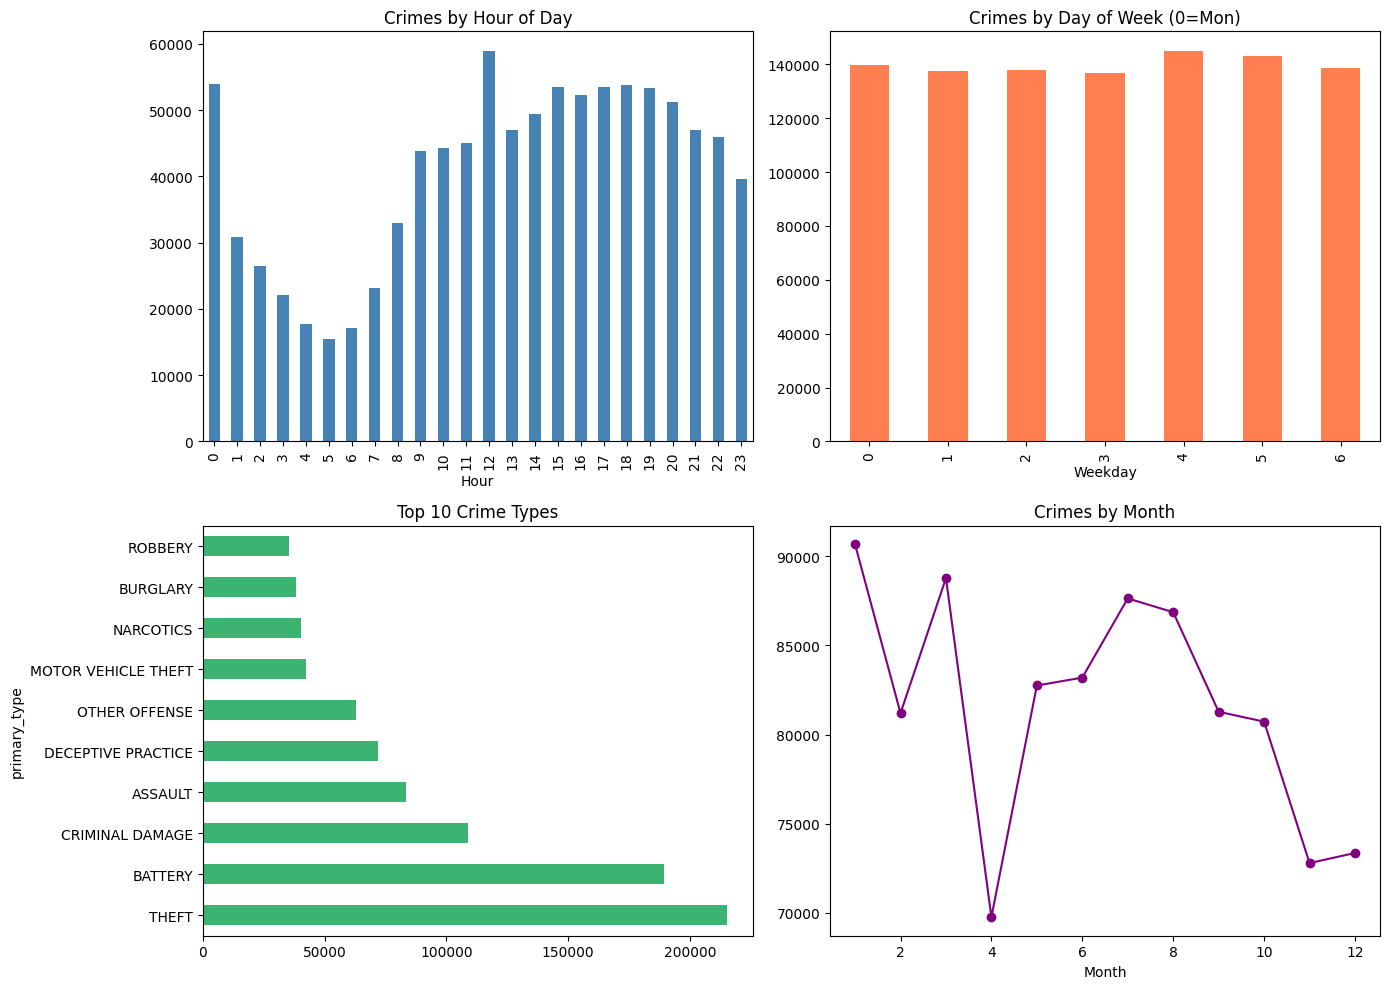

✅ EDA plot saved to Drive


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Crime by hour
df['hour'].value_counts().sort_index().plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Crimes by Hour of Day')
axes[0,0].set_xlabel('Hour')

# 2. Crime by day of week
df['weekday'].value_counts().sort_index().plot(kind='bar', ax=axes[0,1], color='coral')
axes[0,1].set_title('Crimes by Day of Week (0=Mon)')
axes[0,1].set_xlabel('Weekday')

# 3. Top crime types
df['primary_type'].value_counts().head(10).plot(kind='barh', ax=axes[1,0], color='mediumseagreen')
axes[1,0].set_title('Top 10 Crime Types')

# 4. Crime over months
df['month'].value_counts().sort_index().plot(kind='line', marker='o', ax=axes[1,1], color='purple')
axes[1,1].set_title('Crimes by Month')
axes[1,1].set_xlabel('Month')

plt.tight_layout()
plt.savefig(f'{BASE_DIR}/outputs/plots/eda_overview.png', dpi=150)
plt.show()
print('✅ EDA plot saved to Drive')

## 🔧 STEP 5 — Feature Engineering (Grid + Spatial + Temporal)

In [ ]:
# ── Create spatial grid ────────────────────────────────────────────────────────
# Each cell ≈ 500m x 500m
CELL_SIZE = 0.005   # degrees (~500m)

LAT_MIN, LAT_MAX = 41.60, 42.05
LON_MIN, LON_MAX = -87.95, -87.50
df['grid_row'] = ((df['latitude']  - LAT_MIN) / CELL_SIZE).astype(int)
df['grid_col'] = ((df['longitude'] - LON_MIN) / CELL_SIZE).astype(int)
df['cell_id']  = df['grid_row'].astype(str) + '_' + df['grid_col'].astype(str)

GRID_ROWS = df['grid_row'].max() + 1
GRID_COLS = df['grid_col'].max() + 1
print(f'Grid size: {GRID_ROWS} rows × {GRID_COLS} cols = {GRID_ROWS*GRID_COLS} cells')

Grid size: 85 rows × 86 cols = 7310 cells


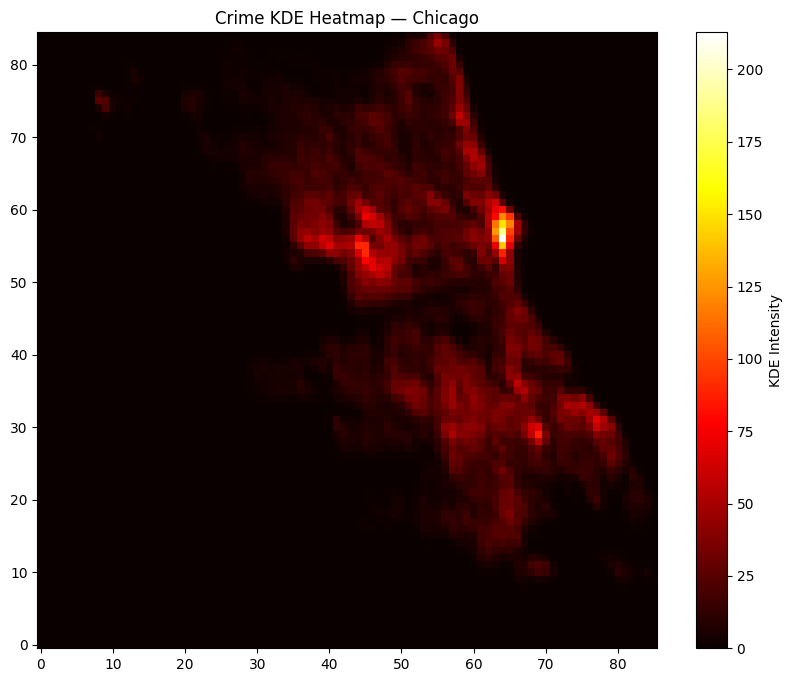

DBSCAN found 13 crime clusters


In [ ]:
from scipy.stats import gaussian_kde
from sklearn.cluster import DBSCAN

# ── KDE Heatmap ────────────────────────────────────────────────────────────────
sample = df.sample(min(50000, len(df)), random_state=42)
coords = sample[['longitude','latitude']].values.T
kde_fn = gaussian_kde(coords, bw_method=0.05)

# Evaluate KDE at each grid cell centroid
cell_lats = LAT_MIN + (np.arange(GRID_ROWS) + 0.5) * CELL_SIZE
cell_lons = LON_MIN + (np.arange(GRID_COLS) + 0.5) * CELL_SIZE
grid_lon_mesh, grid_lat_mesh = np.meshgrid(cell_lons, cell_lats)
kde_grid = kde_fn(np.vstack([grid_lon_mesh.ravel(), grid_lat_mesh.ravel()]))
kde_matrix = kde_grid.reshape(GRID_ROWS, GRID_COLS)

plt.figure(figsize=(10,8))
plt.imshow(kde_matrix, origin='lower', cmap='hot', aspect='auto')
plt.colorbar(label='KDE Intensity')
plt.title('Crime KDE Heatmap — Chicago')
plt.savefig(f'{BASE_DIR}/outputs/plots/kde_heatmap.png', dpi=150)
plt.show()

# ── DBSCAN Clustering ──────────────────────────────────────────────────────────
coords_rad = np.radians(sample[['latitude','longitude']].values)
db = DBSCAN(eps=0.5/6371, algorithm='ball_tree',
            metric='haversine', min_samples=20).fit(coords_rad)
n_clusters = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
print(f'DBSCAN found {n_clusters} crime clusters')

In [ ]:
# ── POI Feature: count nearby POIs per grid cell ───────────────────────────────
from sklearn.neighbors import BallTree

# Build cell centroid array
cell_index = pd.DataFrame([
    {'cell_id': f'{r}_{c}',
     'grid_row': r, 'grid_col': c,
     'lat': LAT_MIN + (r + 0.5) * CELL_SIZE,
     'lon': LON_MIN + (c + 0.5) * CELL_SIZE}
    for r in range(GRID_ROWS) for c in range(GRID_COLS)
])

def count_pois_near_cells(poi_df, tag_col, tag_val, radius_km=0.75):
    subset = poi_df[poi_df[tag_col].astype(str).str.contains(tag_val, na=False)]
    if subset.empty:
        return np.zeros(len(cell_index))
    poi_coords = np.radians(subset[['lat','lon']].values)
    tree = BallTree(poi_coords, metric='haversine')
    cell_coords = np.radians(cell_index[['lat','lon']].values)
    counts = tree.query_radius(cell_coords, r=radius_km/6371, count_only=True)
    return counts

pois['lat'] = pois.geometry.centroid.y
pois['lon'] = pois.geometry.centroid.x

cell_index['poi_bar']     = count_pois_near_cells(pois, 'amenity', 'bar')
cell_index['poi_school']  = count_pois_near_cells(pois, 'amenity', 'school')
cell_index['poi_transit'] = count_pois_near_cells(pois, 'public_transport', 'station')
cell_index['poi_hospital']= count_pois_near_cells(pois, 'amenity', 'hospital')
cell_index['kde_density'] = kde_matrix.ravel()

print(cell_index[['cell_id','lat','lon','poi_bar','poi_school','poi_transit','kde_density']].head())

  cell_id      lat      lon  poi_bar  poi_school  poi_transit  kde_density
0     0_0  41.6025 -87.9475        0           0            0          0.0
1     0_1  41.6025 -87.9425        0           0            0          0.0
2     0_2  41.6025 -87.9375        0           0            0          0.0
3     0_3  41.6025 -87.9325        0           0            0          0.0
4     0_4  41.6025 -87.9275        0           0            0          0.0


In [ ]:
# ── Build Time-Series Feature Matrix ─────────────────────────────────────────
# Aggregate crimes per cell per day (time window = 1 day)
df['date_day'] = df['date'].dt.date

daily = (df.groupby(['cell_id','date_day'])
           .size()
           .reset_index(name='crime_count'))

# Create complete time index (all cells × all days)
all_days   = pd.date_range(df['date'].min().date(), df['date'].max().date(), freq='D')
all_cells  = cell_index['cell_id'].values
full_idx   = pd.MultiIndex.from_product([all_cells, all_days.date],
                                          names=['cell_id','date_day'])
daily = (daily.set_index(['cell_id','date_day'])
              .reindex(full_idx, fill_value=0)
              .reset_index())

# Sort for lag features
daily = daily.sort_values(['cell_id','date_day'])

# Lag features
daily['lag_1']  = daily.groupby('cell_id')['crime_count'].shift(1).fillna(0)
daily['lag_7']  = daily.groupby('cell_id')['crime_count'].shift(7).fillna(0)
daily['lag_14'] = daily.groupby('cell_id')['crime_count'].shift(14).fillna(0)
daily['roll_7'] = (daily.groupby('cell_id')['crime_count']
                       .transform(lambda x: x.shift(1).rolling(7, min_periods=1).mean())
                       .fillna(0))

# Merge temporal features
daily['date_day'] = pd.to_datetime(daily['date_day'])
daily['weekday']  = daily['date_day'].dt.dayofweek
daily['month']    = daily['date_day'].dt.month
daily['season']   = daily['month'].map({12:0,1:0,2:0,3:1,4:1,5:1,
                                          6:2,7:2,8:2,9:3,10:3,11:3})
daily['is_weekend'] = (daily['weekday'] >= 5).astype(int)

# Merge spatial (POI) features
daily = daily.merge(cell_index[['cell_id','poi_bar','poi_school',
                                  'poi_transit','poi_hospital','kde_density',
                                  'grid_row','grid_col']],
                     on='cell_id', how='left')

# Binary target: hotspot if crime_count > 0 in NEXT day
daily['target'] = (daily.groupby('cell_id')['crime_count']
                        .shift(-1)
                        .fillna(0) > 0).astype(int)

# Drop last day (no target) and rows with NaN
daily.dropna(inplace=True)

daily.to_csv(f'{PROC_DIR}/daily_features.csv', index=False)
print(f'✅ Feature matrix: {daily.shape}')
print(f'Hotspot rate: {daily["target"].mean():.2%}')

✅ Feature matrix: (11308570, 19)
Hotspot rate: 6.49%


In [ ]:
import numpy as np
import json

PROC_DIR = f'{BASE_DIR}/data/processed'

# 1. Save daily feature matrix
daily.to_csv(f'{PROC_DIR}/daily_features.csv', index=False)
print(f'✅ Saved daily_features.csv  → {daily.shape}')

# 2. Save cell index (spatial/POI features)
cell_index.to_csv(f'{PROC_DIR}/cell_index.csv', index=False)
print(f'✅ Saved cell_index.csv      → {cell_index.shape}')

# 3. Build grid_tensor (vectorized)
all_dates   = sorted(daily['date_day'].unique())
date_to_idx = {d: i for i, d in enumerate(all_dates)}
T           = len(all_dates)

grid_tensor = np.zeros((T, GRID_ROWS, GRID_COLS), dtype=np.float32)

grid_daily = daily.groupby(['date_day', 'grid_row', 'grid_col'])['crime_count'].sum().reset_index()
print(f'   Filling grid from {len(grid_daily):,} unique (date, cell) combinations...')

for _, row in grid_daily.iterrows():
    t = date_to_idx[row['date_day']]
    r, c = int(row['grid_row']), int(row['grid_col'])
    if r < GRID_ROWS and c < GRID_COLS:
        grid_tensor[t, r, c] = row['crime_count']

grid_tensor /= (grid_tensor.max() + 1e-9)
np.save(f'{PROC_DIR}/grid_tensor.npy', grid_tensor)
print(f'✅ Saved grid_tensor.npy     → {grid_tensor.shape}')

# 4. Save config constants
config = {
    'CELL_SIZE': CELL_SIZE,
    'LAT_MIN': LAT_MIN, 'LAT_MAX': LAT_MAX,
    'LON_MIN': LON_MIN, 'LON_MAX': LON_MAX,
    'GRID_ROWS': int(GRID_ROWS), 'GRID_COLS': int(GRID_COLS),
    'SEQ_LEN': 7
}
with open(f'{PROC_DIR}/config.json', 'w') as f:
    json.dump(config, f)
print('✅ Saved config.json')
print('\n🎉 All features saved. You can now run the modelling notebook independently.')

✅ Saved daily_features.csv  → (11308570, 19)
✅ Saved cell_index.csv      → (7310, 10)
   Filling grid from 11,308,570 unique (date, cell) combinations...
✅ Saved grid_tensor.npy     → (1547, 85, 86)
✅ Saved config.json

🎉 All features saved. You can now run the modelling notebook independently.


## 📐 STEP 6 — Train/Test Split

In [ ]:
# Temporal split: train on older data, test on recent
FEATURE_COLS = ['lag_1','lag_7','lag_14','roll_7',
                'weekday','month','season','is_weekend',
                'poi_bar','poi_school','poi_transit','poi_hospital','kde_density']
TARGET_COL = 'target'

split_date = daily['date_day'].quantile(0.80)  # 80% train

train = daily[daily['date_day'] <= split_date]
test  = daily[daily['date_day'] >  split_date]

X_train, y_train = train[FEATURE_COLS].values, train[TARGET_COL].values
X_test,  y_test  = test[FEATURE_COLS].values,  test[TARGET_COL].values

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Train hotspot rate: {y_train.mean():.2%}  |  Test hotspot rate: {y_test.mean():.2%}')

TypeError: unsupported operand type(s) for -: 'str' and 'str'

## 🔵 STEP 7 — Baseline Models

In [ ]:
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

results = {}

def evaluate(name, y_true, y_proba, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)
    metrics = {
        'AUROC':     round(roc_auc_score(y_true, y_proba), 4),
        'F1':        round(f1_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_true, y_pred, zero_division=0), 4),
    }
    # Hit-Rate@k (top 100 predicted cells)
    k = min(100, len(y_true))
    top_k = np.argsort(y_proba)[-k:]
    metrics['HitRate@100'] = round(y_true[top_k].sum() / max(y_true.sum(), 1), 4)
    results[name] = metrics
    print(f'\n── {name} ──')
    for k,v in metrics.items(): print(f'  {k}: {v}')

# ── Persistence Baseline ───────────────────────────────────────────────────────
y_persist = test['lag_1'].values.astype(float)
y_persist = np.clip(y_persist / (y_persist.max() + 1e-9), 0, 1)
evaluate('Persistence', y_test, y_persist)

# ── Logistic Regression ────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

lr = LogisticRegression(max_iter=500, class_weight='balanced', random_state=42)
lr.fit(X_train_sc, y_train)
evaluate('LogisticRegression', y_test, lr.predict_proba(X_test_sc)[:,1])

print('\n✅ Baselines done')

NameError: name 'test' is not defined

## 🌲 STEP 8 — Random Forest & XGBoost

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import joblib

# ── Random Forest ──────────────────────────────────────────────────────────────
print('Training Random Forest...')
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=10,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)
evaluate('RandomForest', y_test, rf.predict_proba(X_test)[:,1])
joblib.dump(rf, f'{BASE_DIR}/models/random_forest.pkl')

# ── XGBoost ────────────────────────────────────────────────────────────────────
print('\nTraining XGBoost...')
scale_pos = int((y_train==0).sum() / (y_train==1).sum())

xgb_model = xgb.XGBClassifier(
    n_estimators=600,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    tree_method='hist',       # fast on GPU
    device='cuda' if torch.cuda.is_available() else 'cpu',
    eval_metric='auc',
    random_state=42,
    verbosity=0
)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    early_stopping_rounds=30,
    verbose=50
)
evaluate('XGBoost', y_test, xgb_model.predict_proba(X_test)[:,1])
xgb_model.save_model(f'{BASE_DIR}/models/xgboost.json')
print('\n✅ ML models saved to Drive')

Training Random Forest...


NameError: name 'X_train' is not defined

## 🧠 STEP 9 — ConvLSTM (Grid-Based Deep Learning)

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

# ── Build 3D grid tensors ──────────────────────────────────────────────────────
# Shape: (T, GRID_ROWS, GRID_COLS) — daily crime counts on the spatial grid
grid_daily = (daily.groupby(['date_day','grid_row','grid_col'])['crime_count']
                   .sum()
                   .reset_index())
all_dates = sorted(grid_daily['date_day'].unique())

T = len(all_dates)
H = GRID_ROWS
W = GRID_COLS

grid_tensor = np.zeros((T, H, W), dtype=np.float32)
date_to_idx = {d:i for i,d in enumerate(all_dates)}

for _, row in grid_daily.iterrows():
    t = date_to_idx[row['date_day']]
    r, c = int(row['grid_row']), int(row['grid_col'])
    if r < H and c < W:
        grid_tensor[t, r, c] = row['crime_count']

# Normalize
grid_max = grid_tensor.max() + 1e-9
grid_tensor /= grid_max

print(f'Grid tensor shape: {grid_tensor.shape}  (T={T}, H={H}, W={W})')

# ── Dataset ────────────────────────────────────────────────────────────────────
SEQ_LEN = 7   # use 7 days history to predict day 8

class CrimeGridDataset(Dataset):
    def __init__(self, grid, seq_len):
        self.grid    = grid
        self.seq_len = seq_len
    def __len__(self):
        return len(self.grid) - self.seq_len
    def __getitem__(self, idx):
        X = self.grid[idx : idx+self.seq_len]           # (seq, H, W)
        y = (self.grid[idx+self.seq_len] > 0).astype(np.float32) # (H, W)
        return torch.tensor(X).unsqueeze(1), torch.tensor(y).unsqueeze(0)

split_t = int(T * 0.80)
train_ds = CrimeGridDataset(grid_tensor[:split_t], SEQ_LEN)
test_ds  = CrimeGridDataset(grid_tensor[split_t:], SEQ_LEN)

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=4, shuffle=False, num_workers=2)
print(f'Train batches: {len(train_loader)} | Test batches: {len(test_loader)}')

In [ ]:
# ── ConvLSTM Cell ──────────────────────────────────────────────────────────────
class ConvLSTMCell(nn.Module):
    def __init__(self, in_ch, hid_ch, ks=3):
        super().__init__()
        p = ks // 2
        self.hid_ch = hid_ch
        self.conv   = nn.Conv2d(in_ch + hid_ch, 4 * hid_ch, ks, padding=p)

    def forward(self, x, h, c):
        i, f, o, g = self.conv(torch.cat([x,h], dim=1)).chunk(4, dim=1)
        c = torch.sigmoid(f)*c + torch.sigmoid(i)*torch.tanh(g)
        h = torch.sigmoid(o)*torch.tanh(c)
        return h, c

    def init_hidden(self, B, H, W, device):
        return (torch.zeros(B, self.hid_ch, H, W, device=device),
                torch.zeros(B, self.hid_ch, H, W, device=device))

class ConvLSTM(nn.Module):
    def __init__(self, in_ch=1, hid_ch=16, out_ch=1):
        super().__init__()
        self.cell  = ConvLSTMCell(in_ch, hid_ch)
        self.head  = nn.Sequential(
            nn.Conv2d(hid_ch, out_ch, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # x: (B, T, C, H, W)
        B, T, C, H, W = x.shape
        h, c = self.cell.init_hidden(B, H, W, x.device)
        for t in range(T):
            h, c = self.cell(x[:, t], h, c)
        return self.head(h)   # (B, 1, H, W)

conv_lstm = ConvLSTM(in_ch=1, hid_ch=16).to(DEVICE)
print(conv_lstm)
print(f'Parameters: {sum(p.numel() for p in conv_lstm.parameters()):,}')

In [ ]:
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

optimizer  = Adam(conv_lstm.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler  = ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
criterion  = nn.BCELoss()

EPOCHS = 20
train_losses, val_losses = [], []

for epoch in range(1, EPOCHS+1):
    # ── Train ──
    conv_lstm.train()
    tloss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        pred = conv_lstm(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        tloss += loss.item()

    # ── Val ──
    conv_lstm.eval()
    vloss = 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            vloss += criterion(conv_lstm(xb), yb).item()

    tloss /= len(train_loader)
    vloss /= len(test_loader)
    train_losses.append(tloss)
    val_losses.append(vloss)
    scheduler.step(vloss)

    if epoch % 5 == 0:
        print(f'Epoch {epoch:3d} | Train Loss: {tloss:.4f} | Val Loss: {vloss:.4f}')

# Save model
torch.save(conv_lstm.state_dict(), f'{BASE_DIR}/models/convlstm.pt')

# Plot losses
plt.figure(figsize=(8,4))
plt.plot(train_losses, label='Train')
plt.plot(val_losses,   label='Validation')
plt.xlabel('Epoch'); plt.ylabel('BCE Loss')
plt.title('ConvLSTM Training')
plt.legend()
plt.savefig(f'{BASE_DIR}/outputs/plots/convlstm_loss.png', dpi=150)
plt.show()
print('✅ ConvLSTM saved')

## 🕸️ STEP 10 — ST-GNN (Spatio-Temporal Graph Neural Network)

In [ ]:
from torch_geometric.nn import GCNConv, GATConv
from torch_geometric.data import Data
from torch_geometric.utils import add_self_loops

# ── Build spatial graph ────────────────────────────────────────────────────────
# Nodes = grid cells with at least some crime activity
active_cells = (grid_tensor.sum(axis=0) > 0)   # (H, W) boolean
node_rows, node_cols = np.where(active_cells)
N_NODES = len(node_rows)
print(f'Active nodes: {N_NODES}')

# Cell index map: (row, col) → node_id
cell_to_node = {(r,c):i for i,(r,c) in enumerate(zip(node_rows, node_cols))}

# Edges: connect each cell to its 8 neighbours (Moore neighbourhood)
edge_src, edge_dst = [], []
for i,(r,c) in enumerate(zip(node_rows, node_cols)):
    for dr in [-1,0,1]:
        for dc in [-1,0,1]:
            if dr==0 and dc==0: continue
            nb = (r+dr, c+dc)
            if nb in cell_to_node:
                edge_src.append(i)
                edge_dst.append(cell_to_node[nb])

edge_index = torch.tensor([edge_src, edge_dst], dtype=torch.long)
edge_index, _ = add_self_loops(edge_index, num_nodes=N_NODES)
print(f'Edges: {edge_index.shape[1]:,}')

In [ ]:
# ── Build node feature time series ────────────────────────────────────────────
# For each node: last SEQ_LEN days crime counts + static POI features

# Static features per node
cell_index['node_id'] = cell_index.apply(
    lambda row: cell_to_node.get((int(row['grid_row']), int(row['grid_col'])), -1), axis=1
)
node_static = cell_index[cell_index['node_id'] >= 0].sort_values('node_id')
static_feats = node_static[['poi_bar','poi_school','poi_transit',
                              'poi_hospital','kde_density']].values.astype(np.float32)
# Normalize
static_feats = (static_feats - static_feats.mean(0)) / (static_feats.std(0) + 1e-9)

# Dynamic: crime count sequence for each node
node_time = grid_tensor[:, node_rows, node_cols]   # (T, N_NODES)

# Build (X, y) samples: sliding window
XG_list, YG_list = [], []
for t in range(SEQ_LEN, len(node_time)-1):
    seq = node_time[t-SEQ_LEN:t].T          # (N, SEQ_LEN)
    feat = np.concatenate([seq, static_feats], axis=1)  # (N, SEQ_LEN+5)
    target = (node_time[t+1] > 0).astype(np.float32)    # (N,)
    XG_list.append(feat)
    YG_list.append(target)

XG = np.stack(XG_list)   # (samples, N, features)
YG = np.stack(YG_list)   # (samples, N)

split_g = int(len(XG) * 0.80)
XG_train, YG_train = XG[:split_g], YG[:split_g]
XG_test,  YG_test  = XG[split_g:], YG[split_g:]

print(f'GNN Train: {XG_train.shape}  |  GNN Test: {XG_test.shape}')

In [ ]:
# ── ST-GNN Model ───────────────────────────────────────────────────────────────
class STGNN(nn.Module):
    """
    Spatio-Temporal GNN:
      1. GCN layers aggregate spatial neighbourhood info
      2. GRU captures temporal evolution per node
      3. Linear head outputs hotspot probability
    """
    def __init__(self, in_feat, gcn_hid=32, gru_hid=64, out_feat=1):
        super().__init__()
        self.gcn1 = GCNConv(in_feat,  gcn_hid)
        self.gcn2 = GCNConv(gcn_hid,  gcn_hid)
        self.gru  = nn.GRU(gcn_hid, gru_hid, batch_first=True)
        self.head = nn.Linear(gru_hid, out_feat)
        self.drop = nn.Dropout(0.3)

    def forward(self, x_seq, edge_index):
        # x_seq: (N, T, F)
        N, T, F = x_seq.shape
        gcn_out = []
        for t in range(T):
            xt = x_seq[:, t, :]                            # (N, F)
            xt = self.gcn1(xt, edge_index).relu()
            xt = self.drop(self.gcn2(xt, edge_index).relu())
            gcn_out.append(xt.unsqueeze(1))                # (N, 1, gcn_hid)

        gcn_seq = torch.cat(gcn_out, dim=1)               # (N, T, gcn_hid)
        gru_out, _ = self.gru(gcn_seq)                     # (N, T, gru_hid)
        out = torch.sigmoid(self.head(gru_out[:, -1, :]))  # (N, 1)
        return out.squeeze(-1)                             # (N,)

IN_FEAT = SEQ_LEN + static_feats.shape[1]
stgnn = STGNN(in_feat=IN_FEAT).to(DEVICE)
edge_index_dev = edge_index.to(DEVICE)

print(stgnn)
print(f'Parameters: {sum(p.numel() for p in stgnn.parameters()):,}')

In [ ]:
# ── Train ST-GNN ───────────────────────────────────────────────────────────────
opt_gnn  = Adam(stgnn.parameters(), lr=5e-4, weight_decay=1e-4)
sched_gnn = ReduceLROnPlateau(opt_gnn, patience=4, factor=0.5)

# Positive weight to handle class imbalance
pos_w = torch.tensor([(YG_train==0).sum() / (YG_train==1).sum() + 1e-9],
                      dtype=torch.float32).to(DEVICE)
bce   = nn.BCEWithLogitsLoss(pos_weight=pos_w)

GNN_EPOCHS = 30
gnn_train_loss, gnn_val_loss = [], []
BATCH = 16

for epoch in range(1, GNN_EPOCHS+1):
    stgnn.train()
    t_loss = 0
    perm = np.random.permutation(len(XG_train))
    for start in range(0, len(XG_train), BATCH):
        idx = perm[start:start+BATCH]
        xb  = torch.tensor(XG_train[idx]).to(DEVICE)  # (B, N, F)
        yb  = torch.tensor(YG_train[idx]).to(DEVICE)  # (B, N)

        opt_gnn.zero_grad()
        # Process each sample in the batch
        preds = torch.stack([stgnn(xb[i], edge_index_dev) for i in range(len(idx))])
        loss  = bce(preds, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(stgnn.parameters(), 1.0)
        opt_gnn.step()
        t_loss += loss.item()

    # Validation
    stgnn.eval()
    with torch.no_grad():
        xv = torch.tensor(XG_test).to(DEVICE)
        yv = torch.tensor(YG_test).to(DEVICE)
        pv = torch.stack([stgnn(xv[i], edge_index_dev) for i in range(len(xv))])
        v_loss = bce(pv, yv).item()

    gnn_train_loss.append(t_loss / max(len(XG_train)//BATCH, 1))
    gnn_val_loss.append(v_loss)
    sched_gnn.step(v_loss)

    if epoch % 5 == 0:
        print(f'Epoch {epoch:3d} | Train: {gnn_train_loss[-1]:.4f} | Val: {v_loss:.4f}')

torch.save(stgnn.state_dict(), f'{BASE_DIR}/models/stgnn.pt')

# Evaluate
stgnn.eval()
with torch.no_grad():
    xv = torch.tensor(XG_test).to(DEVICE)
    all_preds = torch.stack([stgnn(xv[i], edge_index_dev) for i in range(len(xv))])
    y_gnn_proba = torch.sigmoid(all_preds).cpu().numpy().ravel()
    y_gnn_true  = YG_test.ravel()

evaluate('ST-GNN', y_gnn_true, y_gnn_proba)
print('✅ ST-GNN saved')

## 📊 STEP 11 — Evaluation Summary & SHAP Explainability

In [ ]:
# ── Results Table ──────────────────────────────────────────────────────────────
results_df = pd.DataFrame(results).T
results_df.index.name = 'Model'
print('\n===== MODEL COMPARISON =====')
print(results_df.to_string())
results_df.to_csv(f'{BASE_DIR}/outputs/model_comparison.csv')

# Bar chart
results_df[['AUROC','F1','HitRate@100']].plot(
    kind='bar', figsize=(12,5),
    color=['steelblue','coral','mediumseagreen'],
    edgecolor='black'
)
plt.title('Model Comparison')
plt.xticks(rotation=30)
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/outputs/plots/model_comparison.png', dpi=150)
plt.show()

In [ ]:
import shap

# ── SHAP for XGBoost ───────────────────────────────────────────────────────────
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test[:2000])   # subset for speed

# Summary plot
plt.figure()
shap.summary_plot(shap_values, X_test[:2000],
                  feature_names=FEATURE_COLS,
                  show=False)
plt.savefig(f'{BASE_DIR}/outputs/shap/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# Bar plot of mean |SHAP|
plt.figure()
shap.summary_plot(shap_values, X_test[:2000],
                  feature_names=FEATURE_COLS,
                  plot_type='bar', show=False)
plt.savefig(f'{BASE_DIR}/outputs/shap/shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ SHAP plots saved')

## 🗺️ STEP 12 — Visualization Dashboard (Interactive Maps)

In [ ]:
import folium
from folium.plugins import HeatMap, HeatMapWithTime

# ── Static Hotspot Map (XGBoost predictions) ───────────────────────────────────
test_preds = xgb_model.predict_proba(X_test)[:,1]

# Get lat/lon for test cells
test_meta = test[['cell_id','grid_row','grid_col']].copy()
test_meta = test_meta.merge(cell_index[['cell_id','lat','lon']], on='cell_id', how='left')
test_meta['pred'] = test_preds
test_meta['actual'] = y_test

# Aggregate by cell (mean prediction over all days)
cell_preds = test_meta.groupby(['cell_id','lat','lon'])['pred'].mean().reset_index()

m = folium.Map(location=[41.85, -87.65], zoom_start=11, tiles='CartoDB positron')

# Heatmap layer
heat_data = cell_preds[['lat','lon','pred']].values.tolist()
HeatMap(heat_data, radius=12, blur=8,
        gradient={0.3:'blue', 0.6:'lime', 0.8:'orange', 1.0:'red'}).add_to(m)

# Top 50 hotspot markers
top50 = cell_preds.nlargest(50, 'pred')
for _, row in top50.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=5,
        color='red', fill=True, fill_opacity=0.7,
        popup=f"Hotspot prob: {row['pred']:.2%}"
    ).add_to(m)

MAP_PATH = f'{BASE_DIR}/outputs/maps/hotspot_map.html'
m.save(MAP_PATH)
print(f'✅ Interactive map saved: {MAP_PATH}')

# Display inline
from IPython.display import IFrame
IFrame(MAP_PATH, width=900, height=500)

In [ ]:
# ── Temporal Hotspot Animation ─────────────────────────────────────────────────
# Show how hotspots shift across weekdays
m2 = folium.Map(location=[41.85, -87.65], zoom_start=11, tiles='CartoDB positron')

heat_time_data = []
day_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

for wd in range(7):
    mask = test['weekday'] == wd
    sub  = test_meta[mask.values]
    heat_time_data.append(
        sub[['lat','lon','pred']].dropna().values.tolist()
    )

HeatMapWithTime(
    heat_time_data,
    index=day_labels,
    radius=10,
    gradient={0.3:'blue', 0.6:'lime', 1.0:'red'},
    min_opacity=0.3
).add_to(m2)

MAP2_PATH = f'{BASE_DIR}/outputs/maps/temporal_hotspot.html'
m2.save(MAP2_PATH)
print(f'✅ Temporal animation saved: {MAP2_PATH}')
IFrame(MAP2_PATH, width=900, height=500)

## ✅ STEP 13 — Final Summary

```
📁 CrimeHotspot/
├── data/
│   ├── raw/         ← chicago_crimes.csv, chicago_pois.gpkg
│   └── processed/   ← daily_features.csv
├── models/
│   ├── random_forest.pkl
│   ├── xgboost.json
│   ├── convlstm.pt
│   └── stgnn.pt
└── outputs/
    ├── model_comparison.csv
    ├── maps/        ← hotspot_map.html, temporal_hotspot.html
    ├── plots/       ← eda, loss curves, model comparison
    └── shap/        ← shap_summary.png, shap_bar.png
```

All outputs are saved to your **Google Drive** automatically.

### 📌 Next Steps
- Add LA Crime Dataset for cross-city validation
- Add census demographic features (population density, income)
- Run ablation study: remove POI features and compare AUROC drop
- Use GNNExplainer for ST-GNN interpretability

In [ ]:
# ── Ablation Study ─────────────────────────────────────────────────────────────
print('Running ablation: XGBoost WITHOUT spatial/POI features...')

TEMPORAL_ONLY = ['lag_1','lag_7','lag_14','roll_7','weekday','month','season','is_weekend']

xgb_abl = xgb.XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    scale_pos_weight=scale_pos, tree_method='hist',
    device='cuda' if torch.cuda.is_available() else 'cpu',
    verbosity=0, random_state=42
)
xgb_abl.fit(train[TEMPORAL_ONLY].values, y_train)
evaluate('XGBoost_NoPOI', y_test, xgb_abl.predict_proba(test[TEMPORAL_ONLY].values)[:,1])

print('\n── Impact of spatial features ──')
full_auc = results['XGBoost']['AUROC']
abl_auc  = results['XGBoost_NoPOI']['AUROC']
print(f'AUROC with POI features:    {full_auc}')
print(f'AUROC without POI features: {abl_auc}')
print(f'AUROC gain from POI:        +{full_auc - abl_auc:.4f}')